# RegVelo Schwann downstream analysis after DFFP scoring

This notebook is a dedicated downstream-analysis guide for the curated
`Common Progenitor → Gut, Gut neuron, ChC` furcation.

The primary model is dynamical RNA velocity. Inverse CytoTRACE is used as the
validated ordering for this benchmark only. Gut retrograde Signed Ordering Flux
is retained as biological information rather than corrected away.

> **Execution provenance.** The displayed outputs were generated with scCS 0.8.0.dev33. Version 0.8.0.dev34 changes documentation and tutorial explanation only; the scientific calculations are unchanged.

## 1. Installation, versions, and reproducibility


In [1]:
from __future__ import annotations
import warnings

from pathlib import Path
import importlib.metadata as importlib_metadata
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
from scipy.spatial.distance import jensenshannon

import scCS

SEED = 20260714
N_JOBS = 1
sc.settings.verbosity = 2
scv.settings.verbosity = 2
sc.set_figure_params(dpi=100, facecolor="white")

print("Python", sys.version.split()[0])
print("Platform", platform.platform())
print("scCS", scCS.__version__)
print("Scanpy", importlib_metadata.version("scanpy"))
print("scVelo", scv.__version__)

OUTPUT_DIR = Path("tutorial_outputs/schwann_downstream")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Hide known warnings emitted by optional upstream dependencies. These do not
# change the scCS calculation and would otherwise distract from the tutorial.
warnings.filterwarnings(
    "ignore",
    message=r"This process .* is multi-threaded, use of fork\(\) may lead to deadlocks.*",
    category=DeprecationWarning,
)
warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module=r"cellrank\..*",
)


Python 3.12.13
Platform Linux-6.6.114.1-microsoft-standard-WSL2-x86_64-with-glibc2.39
scCS 0.8.0.dev33
Scanpy 1.11.5
scVelo 0.3.4


## 2. Load RegVelo Schwann, reproduce the curated clusters, and fit velocity

The Schwann tutorials use **dynamical RNA velocity** as the primary model.
The dataset is loaded directly from RegVelo and the velocity model is fitted in
the original expression/PCA manifold. No tutorial cache is assumed.

The inverse-CytoTRACE coordinate is used only as the validated ordering for this
particular furcation; scCS does not prescribe it as a universal pseudotime.



In [2]:
def clear_velocity_outputs(adata, *, clear_dynamics=False):
    """Remove stale velocity fields before fitting a requested model."""
    for key in ("velocity", "velocity_u", "velocity_variance"):
        adata.layers.pop(key, None)
    for key in ("velocity_graph", "velocity_graph_neg", "velocity_params"):
        adata.uns.pop(key, None)
    for key in (
        "velocity_self_transition",
        "root_cells",
        "end_points",
        "velocity_pseudotime",
        "latent_time",
    ):
        if key in adata.obs:
            del adata.obs[key]
    if clear_dynamics:
        for key in list(adata.var.columns):
            if str(key).startswith("fit_"):
                del adata.var[key]
        for key in list(adata.layers):
            if str(key).startswith("fit_"):
                del adata.layers[key]
        adata.uns.pop("recover_dynamics", None)


def ensure_pca_neighbors_moments(
    adata,
    *,
    n_pcs=30,
    n_neighbors=30,
    preserve_existing_neighbors=False,
):
    """Create the unbiased PCA neighbor graph used by RNA velocity."""
    if "X_pca" not in adata.obsm:
        n_comps = min(n_pcs, adata.n_obs - 1, adata.n_vars - 1)
        sc.pp.pca(adata, n_comps=n_comps)
    if "neighbors" not in adata.uns or not preserve_existing_neighbors:
        sc.pp.neighbors(
            adata,
            n_neighbors=min(n_neighbors, adata.n_obs - 1),
            n_pcs=min(n_pcs, adata.obsm["X_pca"].shape[1]),
            use_rep="X_pca",
            random_state=SEED,
        )
    if not {"Ms", "Mu"}.issubset(adata.layers):
        scv.pp.moments(adata, n_neighbors=None, n_pcs=None)
    if "X_umap" not in adata.obsm:
        sc.tl.umap(adata, random_state=SEED)


def resolve_present_genes(adata, candidates):
    """Resolve gene symbols case-insensitively and report missing markers."""
    lookup = {str(gene).lower(): str(gene) for gene in adata.var_names}
    resolved, missing = [], []
    for candidate in candidates:
        match = lookup.get(str(candidate).lower())
        if match is None:
            missing.append(str(candidate))
        elif match not in resolved:
            resolved.append(match)
    return resolved, missing


def row_js(left, right):
    """Row-wise Jensen-Shannon divergence with base-2 logarithms."""
    return np.asarray(
        [jensenshannon(a, b, base=2.0) ** 2 for a, b in zip(left, right)],
        dtype=float,
    )


def ordering_thirds(values):
    """Return stable early/middle/late labels for a continuous coordinate."""
    series = pd.Series(np.asarray(values, dtype=float))
    ranked = series.rank(method="first")
    return (
        pd.qcut(
            ranked,
            q=3,
            labels=["early", "middle", "late"],
            duplicates="drop",
        )
        .astype(str)
        .to_numpy()
    )

In [3]:
import regvelo as rgv

SCHWANN_CLUSTER_ANNOTATION = {
    "15": "Common Progenitor",
    "5": "Common Progenitor",
    "16": "Gut",
    "12": "Gut neuron",
    "8": "ChC",
    "6": "ChC",
}
VELOCITY_MODEL = "dynamical"
RECOVER_DYNAMICS_MAX_ITER = 20


def prepare_schwann_annotations(adata):
    """Reproduce the curated Schwann furcation and inverse-CytoTRACE ordering."""
    if "neighbors" not in adata.uns or "connectivities" not in adata.obsp:
        raise RuntimeError("The original RegVelo neighbor graph is required.")

    if "sccs_leiden" not in adata.obs:
        sc.tl.leiden(
            adata,
            resolution=1.0,
            random_state=0,
            key_added="sccs_leiden",
        )

    leiden = adata.obs["sccs_leiden"].astype(str)
    adata.obs["cell_type_new"] = (
        leiden.map(SCHWANN_CLUSTER_ANNOTATION).fillna("Other").astype("category")
    )

    required = ("Common Progenitor", "Gut", "Gut neuron", "ChC")
    counts = adata.obs["cell_type_new"].astype(str).value_counts().reindex(required, fill_value=0)
    if np.any(counts <= 0):
        raise ValueError(
            f"The curated furcation was not reproduced. Observed counts: {counts.to_dict()}"
        )

    cytotrace = pd.to_numeric(adata.obs["CytoTRACE"], errors="coerce").to_numpy(float)
    finite = np.isfinite(cytotrace)
    lower = float(np.nanmin(cytotrace))
    upper = float(np.nanmax(cytotrace))
    inverse = np.full(adata.n_obs, np.nan, dtype=float)
    inverse[finite] = 1.0 - (cytotrace[finite] - lower) / (upper - lower)
    adata.obs["inverse_cytotrace_pseudotime"] = inverse


# Load the public RegVelo Schwann dataset and reproduce the curated annotations.
adata = rgv.datasets.schwann()
adata.var_names_make_unique()
prepare_schwann_annotations(adata)

# Fit the dynamical model in the original expression/PCA manifold.
# This is the primary Schwann model used by the tutorials.
ensure_pca_neighbors_moments(
    adata,
    n_pcs=30,
    n_neighbors=30,
    preserve_existing_neighbors=True,
)
clear_velocity_outputs(adata, clear_dynamics=True)
scv.tl.recover_dynamics(
    adata,
    max_iter=RECOVER_DYNAMICS_MAX_ITER,
    n_jobs=N_JOBS,
)
scv.tl.velocity(adata, mode="dynamical")
scv.tl.velocity_graph(adata, n_jobs=N_JOBS)
prepare_schwann_annotations(adata)

print(adata)
display(adata.obs["cell_type_new"].astype(str).value_counts().to_frame("n_cells"))

running Leiden clustering
    finished (0:00:02)
recovering dynamics (using 1/24 cores)


  0%|          | 0/1141 [00:00<?, ?gene/s]

    finished (0:24:05)
computing velocities
    finished (0:00:11)
computing velocity graph (using 1/24 cores)


  0%|          | 0/8821 [00:00<?, ?cells/s]

    finished (0:00:14)
AnnData object with n_obs × n_vars = 8821 × 1150
    obs: 'plates', 'devtime', 'location', 'n_genes_by_counts', 'total_counts', 'total_counts_ERCC', 'pct_counts_ERCC', 'doublet_scores', 'leiden', 'CytoTRACE', 'Gut_neuron', 'Sensory', 'Symp', 'enFib', 'ChC', 'Gut_glia', 'NCC', 'Mesenchyme', 'Melanocytes', 'SatGlia', 'SC', 'BCC', 'conflict', 'assignments', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'sccs_leiden', 'cell_type_new', 'inverse_cytotrace_pseudotime', 'velocity_self_transition'
    var: 'ERCC', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'm', 'v', 'n_obs', 'res', 'lp', 'lpa', 'qv', 'highly_variable', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'TF', 'means', 'dispersions', 'dispersions_norm', 'velocity_genes', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_s

,n_cells
cell_type_new,
Other,6845
ChC,762
Common Progenitor,675
Gut neuron,294
Gut,245


## 3. Inspect the native manifold and curated topology


inverse_cytotrace_pseudotime                              
                                         count    median       min       max
cell_type_new                                                               
ChC                                        762  0.607434  0.276986  0.829939
Common Progenitor                          675  0.420570  0.267821  0.853360
Gut                                        245  0.797352  0.459267  0.875764
Gut neuron                                 294  0.525967  0.336049  0.779022

computing velocity embedding
    finished (0:00:01)


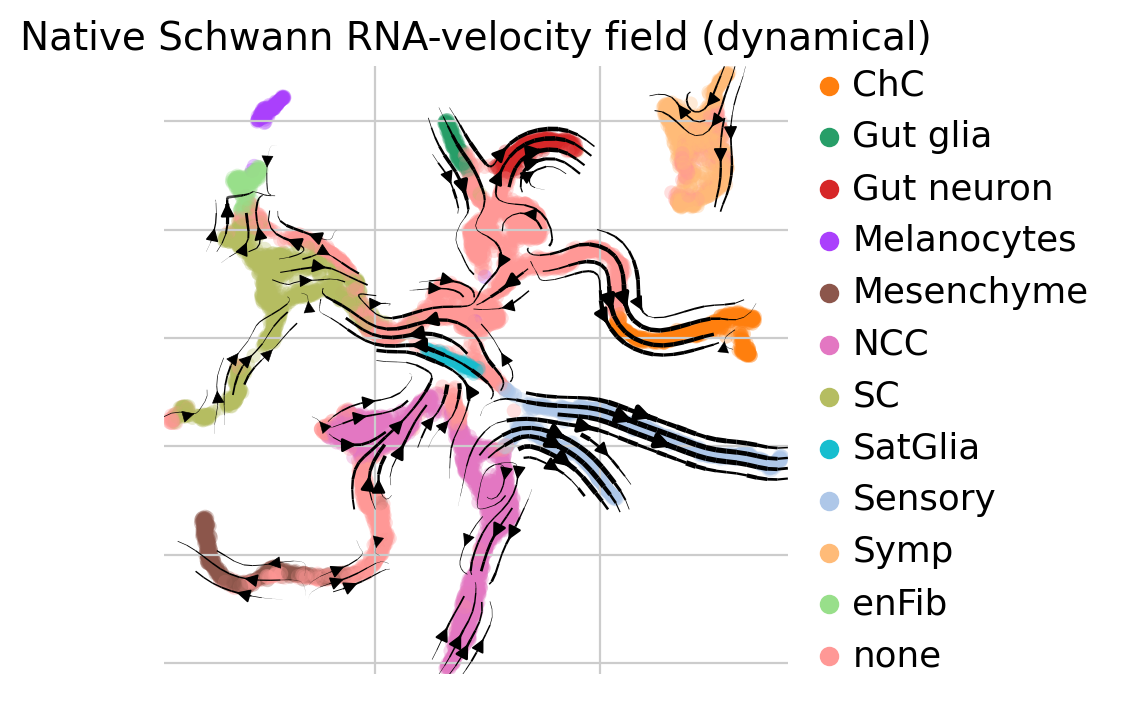

In [4]:
selected_labels = ["Common Progenitor", "Gut", "Gut neuron", "ChC"]
selected_mask_full = adata.obs["cell_type_new"].astype(str).isin(selected_labels)
display(
    adata.obs.loc[
        selected_mask_full,
        ["cell_type_new", "inverse_cytotrace_pseudotime"],
    ]
    .groupby("cell_type_new", observed=True)
    .agg(["count", "median", "min", "max"])
)

color_key = "assignments" if "assignments" in adata.obs else "cell_type_new"
scv.pl.velocity_embedding_stream(
    adata,
    basis="umap",
    color=color_key,
    legend_loc="right margin",
    title=f"Native Schwann RNA-velocity field ({VELOCITY_MODEL})",
)

## 4. Define the supervised furcation and run preflight diagnostics


In [5]:
ROOT = "Common Progenitor"
FATES = ["Gut", "Gut neuron", "ChC"]
ORDERING_KEY = "inverse_cytotrace_pseudotime"

scorer = scCS.SingleScorer(
    adata,
    root=ROOT,
    branches=FATES,
    obs_key="cell_type_new",
)
preflight = scorer.preflight(ordering_metric=ORDERING_KEY, check_velocity=True)
preflight.display()
preflight.raise_for_errors()
scorer.build_embedding(
    ordering_metric=ORDERING_KEY,
    write_to_adata=True,
)

,level,code,message,value
0,info,furcation_valid,Root and terminal annotations are valid.,1976.000000
1,info,root_cells,Root population contains 675 cells.,675.000000
2,info,terminal_Gut,Terminal 'Gut' contains 245 cells.,245.000000
3,info,terminal_Gut neuron,Terminal 'Gut neuron' contains 294 cells.,294.000000
4,info,terminal_ChC,Terminal 'ChC' contains 762 cells.,762.000000
5,info,ordering_valid,Ordering metric is finite and non-constant amo...,1.000000
6,info,ordering_resolution,Root ordering has 337 unique values across 675...,0.499259
7,info,velocity_available,Velocity information is available.,NaN


[scCS] Scientific star built for 1976 cells in 3 dimensions.
       Root radial clipping: 0.050 low / 0.050 high
       Terminal scientific coordinates: fixed equal-radius simplex vertices (radius=1.000).


## 5. Fit discounted future-fate scoring


In [6]:
FUTURE_OPTIONS = {
    "effective_horizon": 64,
    "anchor_quantile": 0.90,
    "min_anchor_cells": 10,
    "progression_scale": "rank",
    "committed_reach_threshold": 0.25,
    "committed_specificity_threshold": 0.25,
}
scorer.fit(
    scoring_mode="future_fate",
    future_fate_options=FUTURE_OPTIONS,
)
result = scorer.score(write_to_adata=True)
display(pd.Series(result.summary(), name="value").to_frame())
anchor_diagnostics = result.anchor_diagnostics_frame()
display(anchor_diagnostics)
anchor_diagnostics.to_csv(OUTPUT_DIR / "anchor_diagnostics.csv", index=False)

scCS FutureFateScoreResult
  Furcation: Common Progenitor -> ['Gut', 'Gut neuron', 'ChC']
  Effective horizon: 64 (gamma=0.984615)
  Cells: 1976 selected; 675 root
  Root affinity coverage: 1.000
  Root mean future-fate reach: 0.156
  Root mean future-fate entropy: 0.877
  Root mean future-fate specificity: 0.123
  Root mean reach-supported specificity: 0.025
  Root mean unresolved probability: 0.844
  Root mean signed progression: 0.020
  Root future-fate composition: Gut=0.139, Gut neuron=0.365, ChC=0.496
  Solver: direct; iterations=1; residual=3.315e-15
scCS FutureFateScoreResult
  Furcation: Common Progenitor -> ['Gut', 'Gut neuron', 'ChC']
  Effective horizon: 64 (gamma=0.984615)
  Cells: 1976 selected; 675 root
  Root affinity coverage: 1.000
  Root mean future-fate reach: 0.156
  Root mean future-fate entropy: 0.877
  Root mean future-fate specificity: 0.123
  Root mean reach-supported specificity: 0.025
  Root mean unresolved probability: 0.844
  Root mean signed progression: 

,value
0,scCS FutureFateScoreResult\n Furcation: Commo...


,fate,n_anchors,mean_transition_to_same_fate_population,mean_transition_to_root,mean_transition_to_other_selected_fates,mean_transition_outside_selected_path,mean_signed_progression,forward_fraction
0,Gut,26,0.919012,0.046293,0.000000,0.034694,-0.112502,0.0
1,Gut neuron,30,0.879802,0.000610,0.009397,0.110191,-0.123093,0.0
2,ChC,79,0.948219,0.000000,0.000000,0.051781,-0.084801,0.0


## 6. Record the DFFP state before downstream analysis

In [7]:
summary_table = pd.DataFrame(
    {
        "cell_id": result.cell_ids,
        "population": np.where(
            result.root_mask,
            "root",
            result.embedding.terminal_names.astype(str),
        ),
        "DFR": result.discounted_fate_reach,
        "FFS": result.future_fate_specificity,
        "RC": result.resolved_commitment,
        "UFP": result.unresolved_future_probability,
        "SOF": result.signed_ordering_flux,
    }
)
for fate_index, fate in enumerate(result.fate_names):
    summary_table[f"CFA:{fate}"] = result.conditional_fate_affinity[:, fate_index]
display(summary_table.groupby("population", observed=True).agg(
    n_cells=("DFR", "size"),
    mean_DFR=("DFR", "mean"),
    mean_FFS=("FFS", "mean"),
    mean_RC=("RC", "mean"),
    mean_SOF=("SOF", "mean"),
))
display(result.anchor_diagnostics_frame())

,n_cells,mean_DFR,mean_FFS,mean_RC,mean_SOF
population,,,,,
ChC,762,0.807670,0.874619,0.744100,0.039342
Gut,245,0.387852,0.211938,0.149273,-0.155898
Gut neuron,294,0.779802,0.798632,0.639331,0.029544
root,675,0.155633,0.122960,0.024555,0.020214


,fate,n_anchors,mean_transition_to_same_fate_population,mean_transition_to_root,mean_transition_to_other_selected_fates,mean_transition_outside_selected_path,mean_signed_progression,forward_fraction
0,Gut,26,0.919012,0.046293,0.000000,0.034694,-0.112502,0.0
1,Gut neuron,30,0.879802,0.000610,0.009397,0.110191,-0.123093,0.0
2,ChC,79,0.948219,0.000000,0.000000,0.051781,-0.084801,0.0


## 7. Curated neural-crest, neuronal, enteric, and glial markers

The marker list is intentionally broader than the three supervised fates. This
helps reveal whether outside neural-crest programs are retained within the
selected trajectory.

In [8]:
marker_candidates = {
    "neural_crest_progenitor": ["Sox10", "Foxd3", "Tfap2a", "Plp1", "Erbb3"],
    "enteric_neuron": ["Phox2b", "Ret", "Tubb3", "Elavl3", "Elavl4"],
    "catecholaminergic": ["Th", "Dbh", "Chga", "Chgb", "Slc18a2"],
    "glial_schwann": ["Sox10", "Plp1", "S100b", "Fabp7", "Mpz"],
    "neuronal_maturation": ["Tubb3", "Map2", "Stmn2", "Snap25", "Syp"],
}
resolved_groups = {}
missing_groups = {}
for group, candidates in marker_candidates.items():
    resolved, missing = resolve_present_genes(adata, candidates)
    resolved_groups[group] = resolved
    missing_groups[group] = missing

display(
    pd.DataFrame(
        {
            "resolved": {key: ", ".join(value) for key, value in resolved_groups.items()},
            "missing": {key: ", ".join(value) for key, value in missing_groups.items()},
        }
    )
)
markers = list(dict.fromkeys(gene for genes in resolved_groups.values() for gene in genes))

,resolved,missing
neural_crest_progenitor,Tfap2a,"Sox10, Foxd3, Plp1, Erbb3"
enteric_neuron,"Phox2b, Ret, Tubb3, Elavl3, Elavl4",
catecholaminergic,"Dbh, Chga, Chgb, Slc18a2",Th
glial_schwann,"Fabp7, Mpz","Sox10, Plp1, S100b"
neuronal_maturation,"Tubb3, Stmn2, Snap25, Syp",Map2


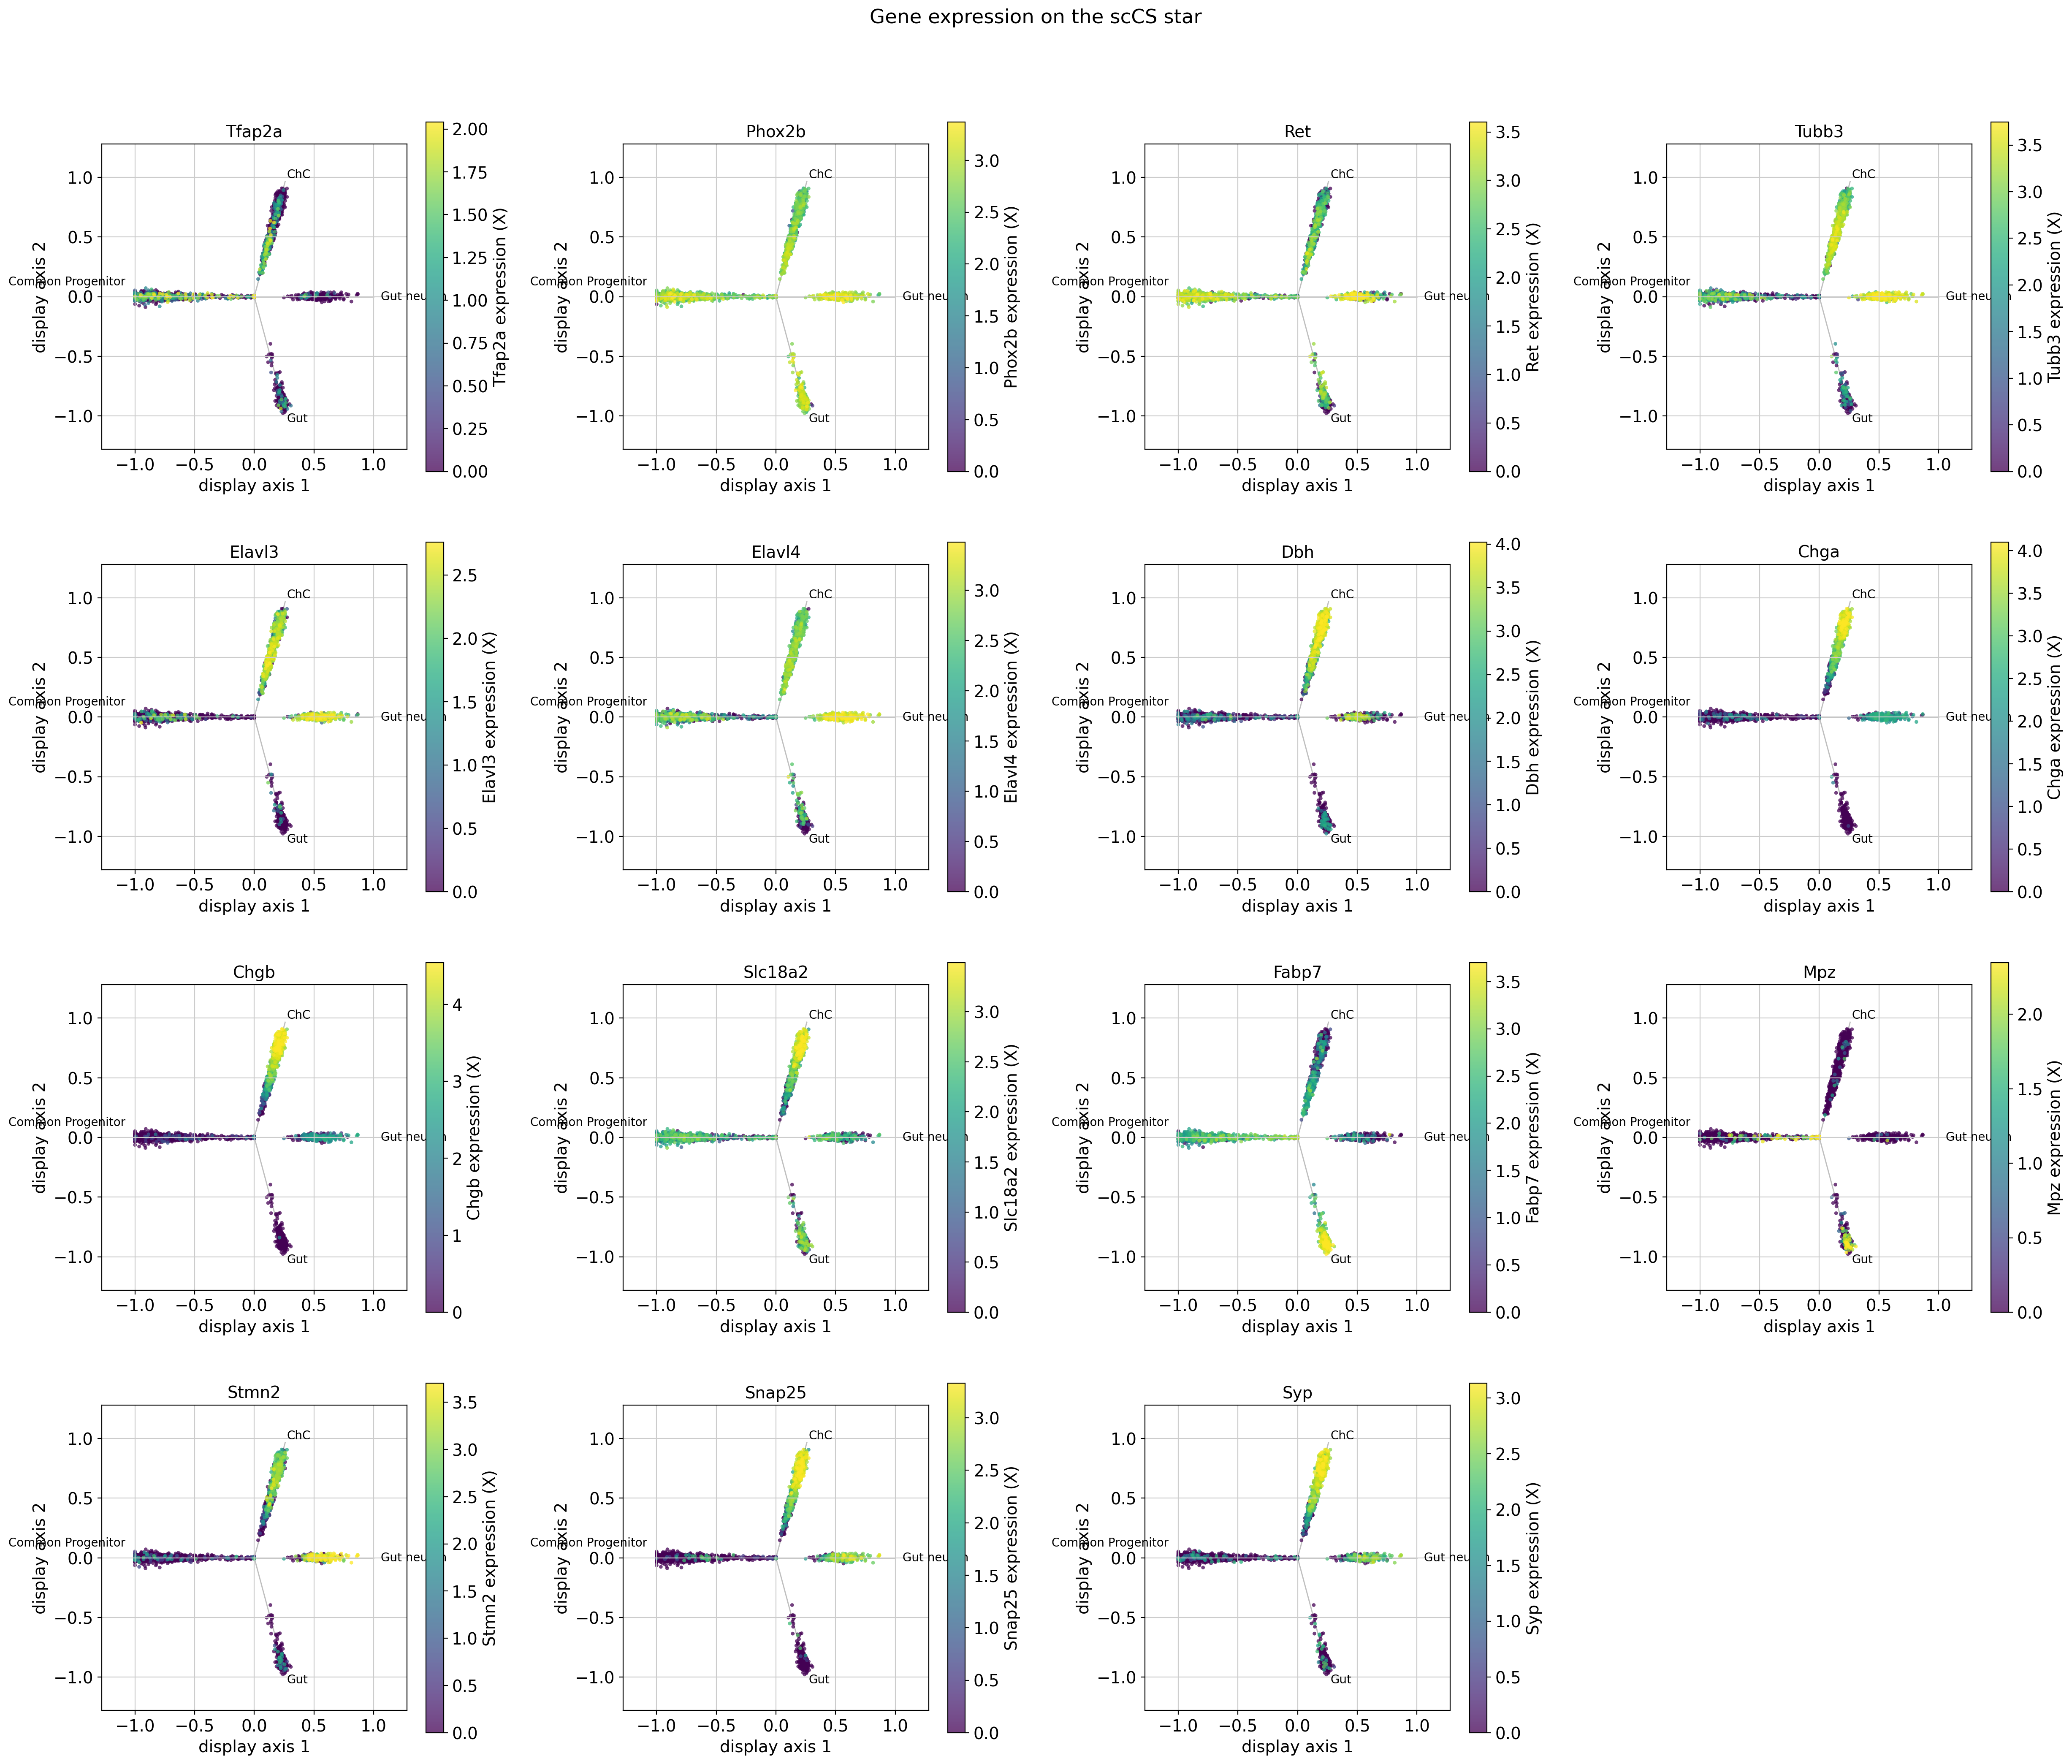

In [9]:
marker_figure = scorer.plot_gene_expression_star(
    markers,
    result,
    ncols=4,
    shared_scale=False,
    terminal_layout="ordering",
)
marker_figure.savefig(
    OUTPUT_DIR / "downstream_marker_expression_stars.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## 8. Expression trends along inverse CytoTRACE and fate affinity

The ordering is dataset-specific. A trend along inverse CytoTRACE is not
automatically a general developmental program outside this selected furcation.

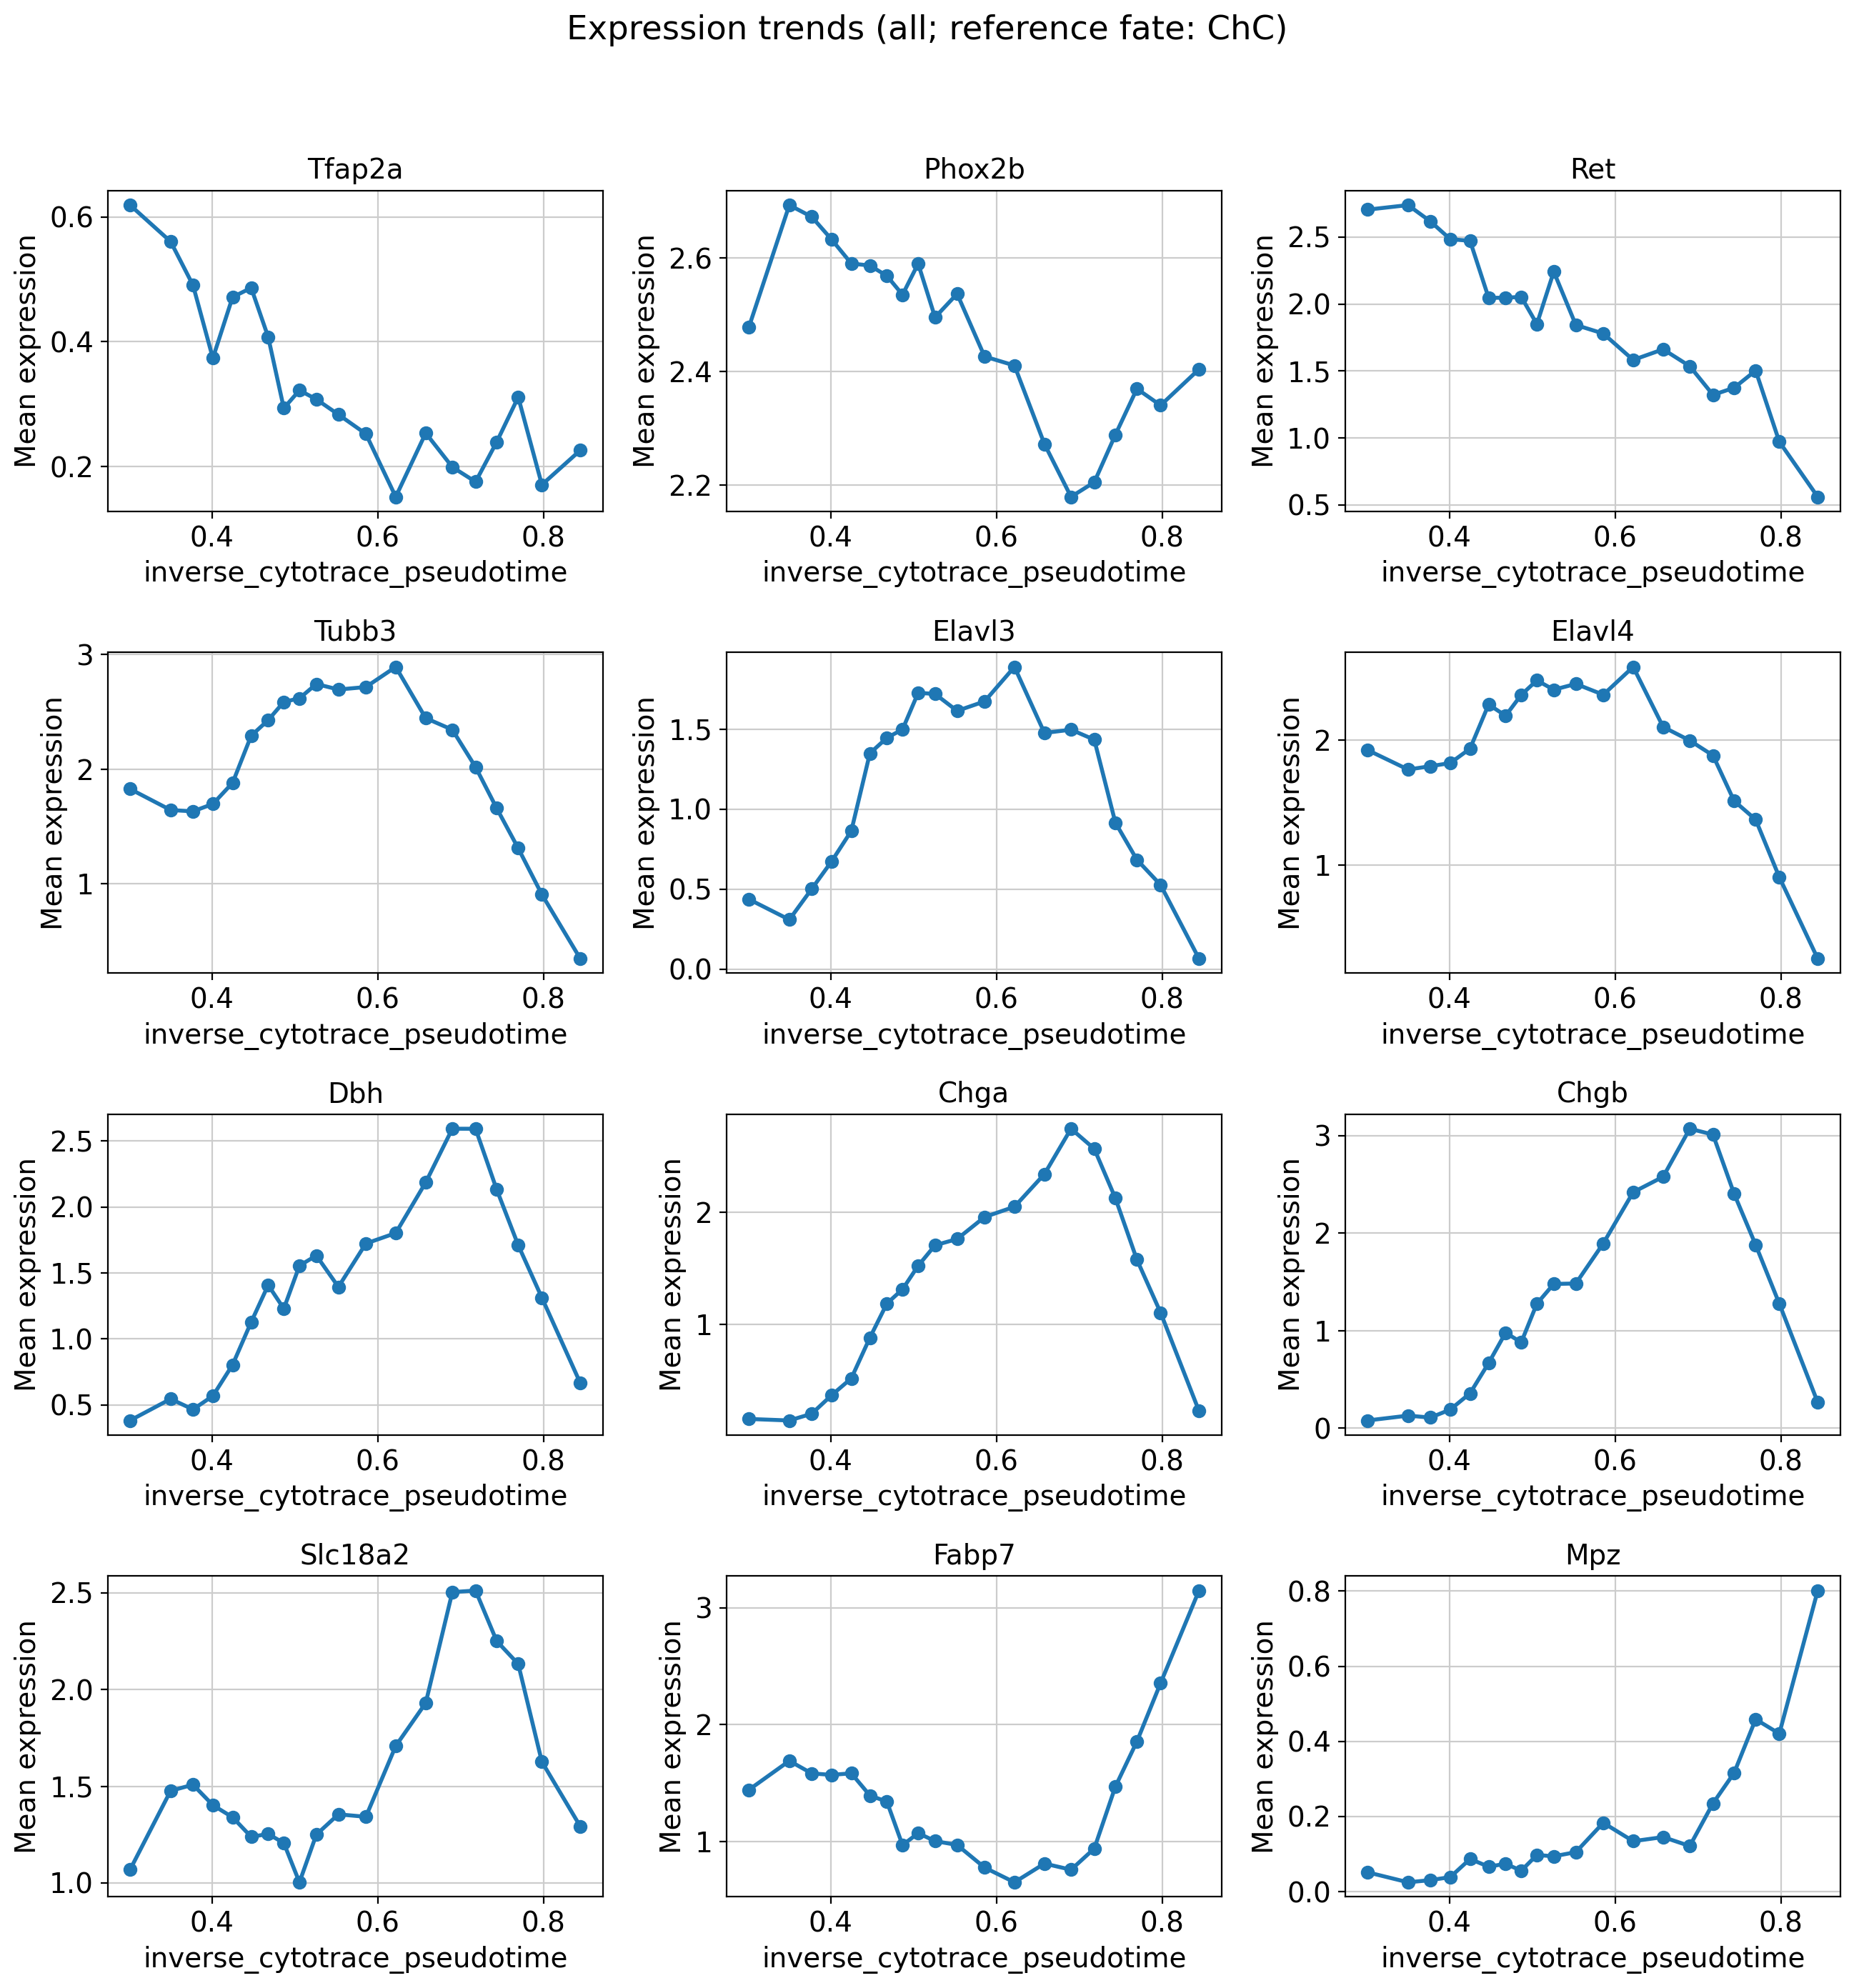

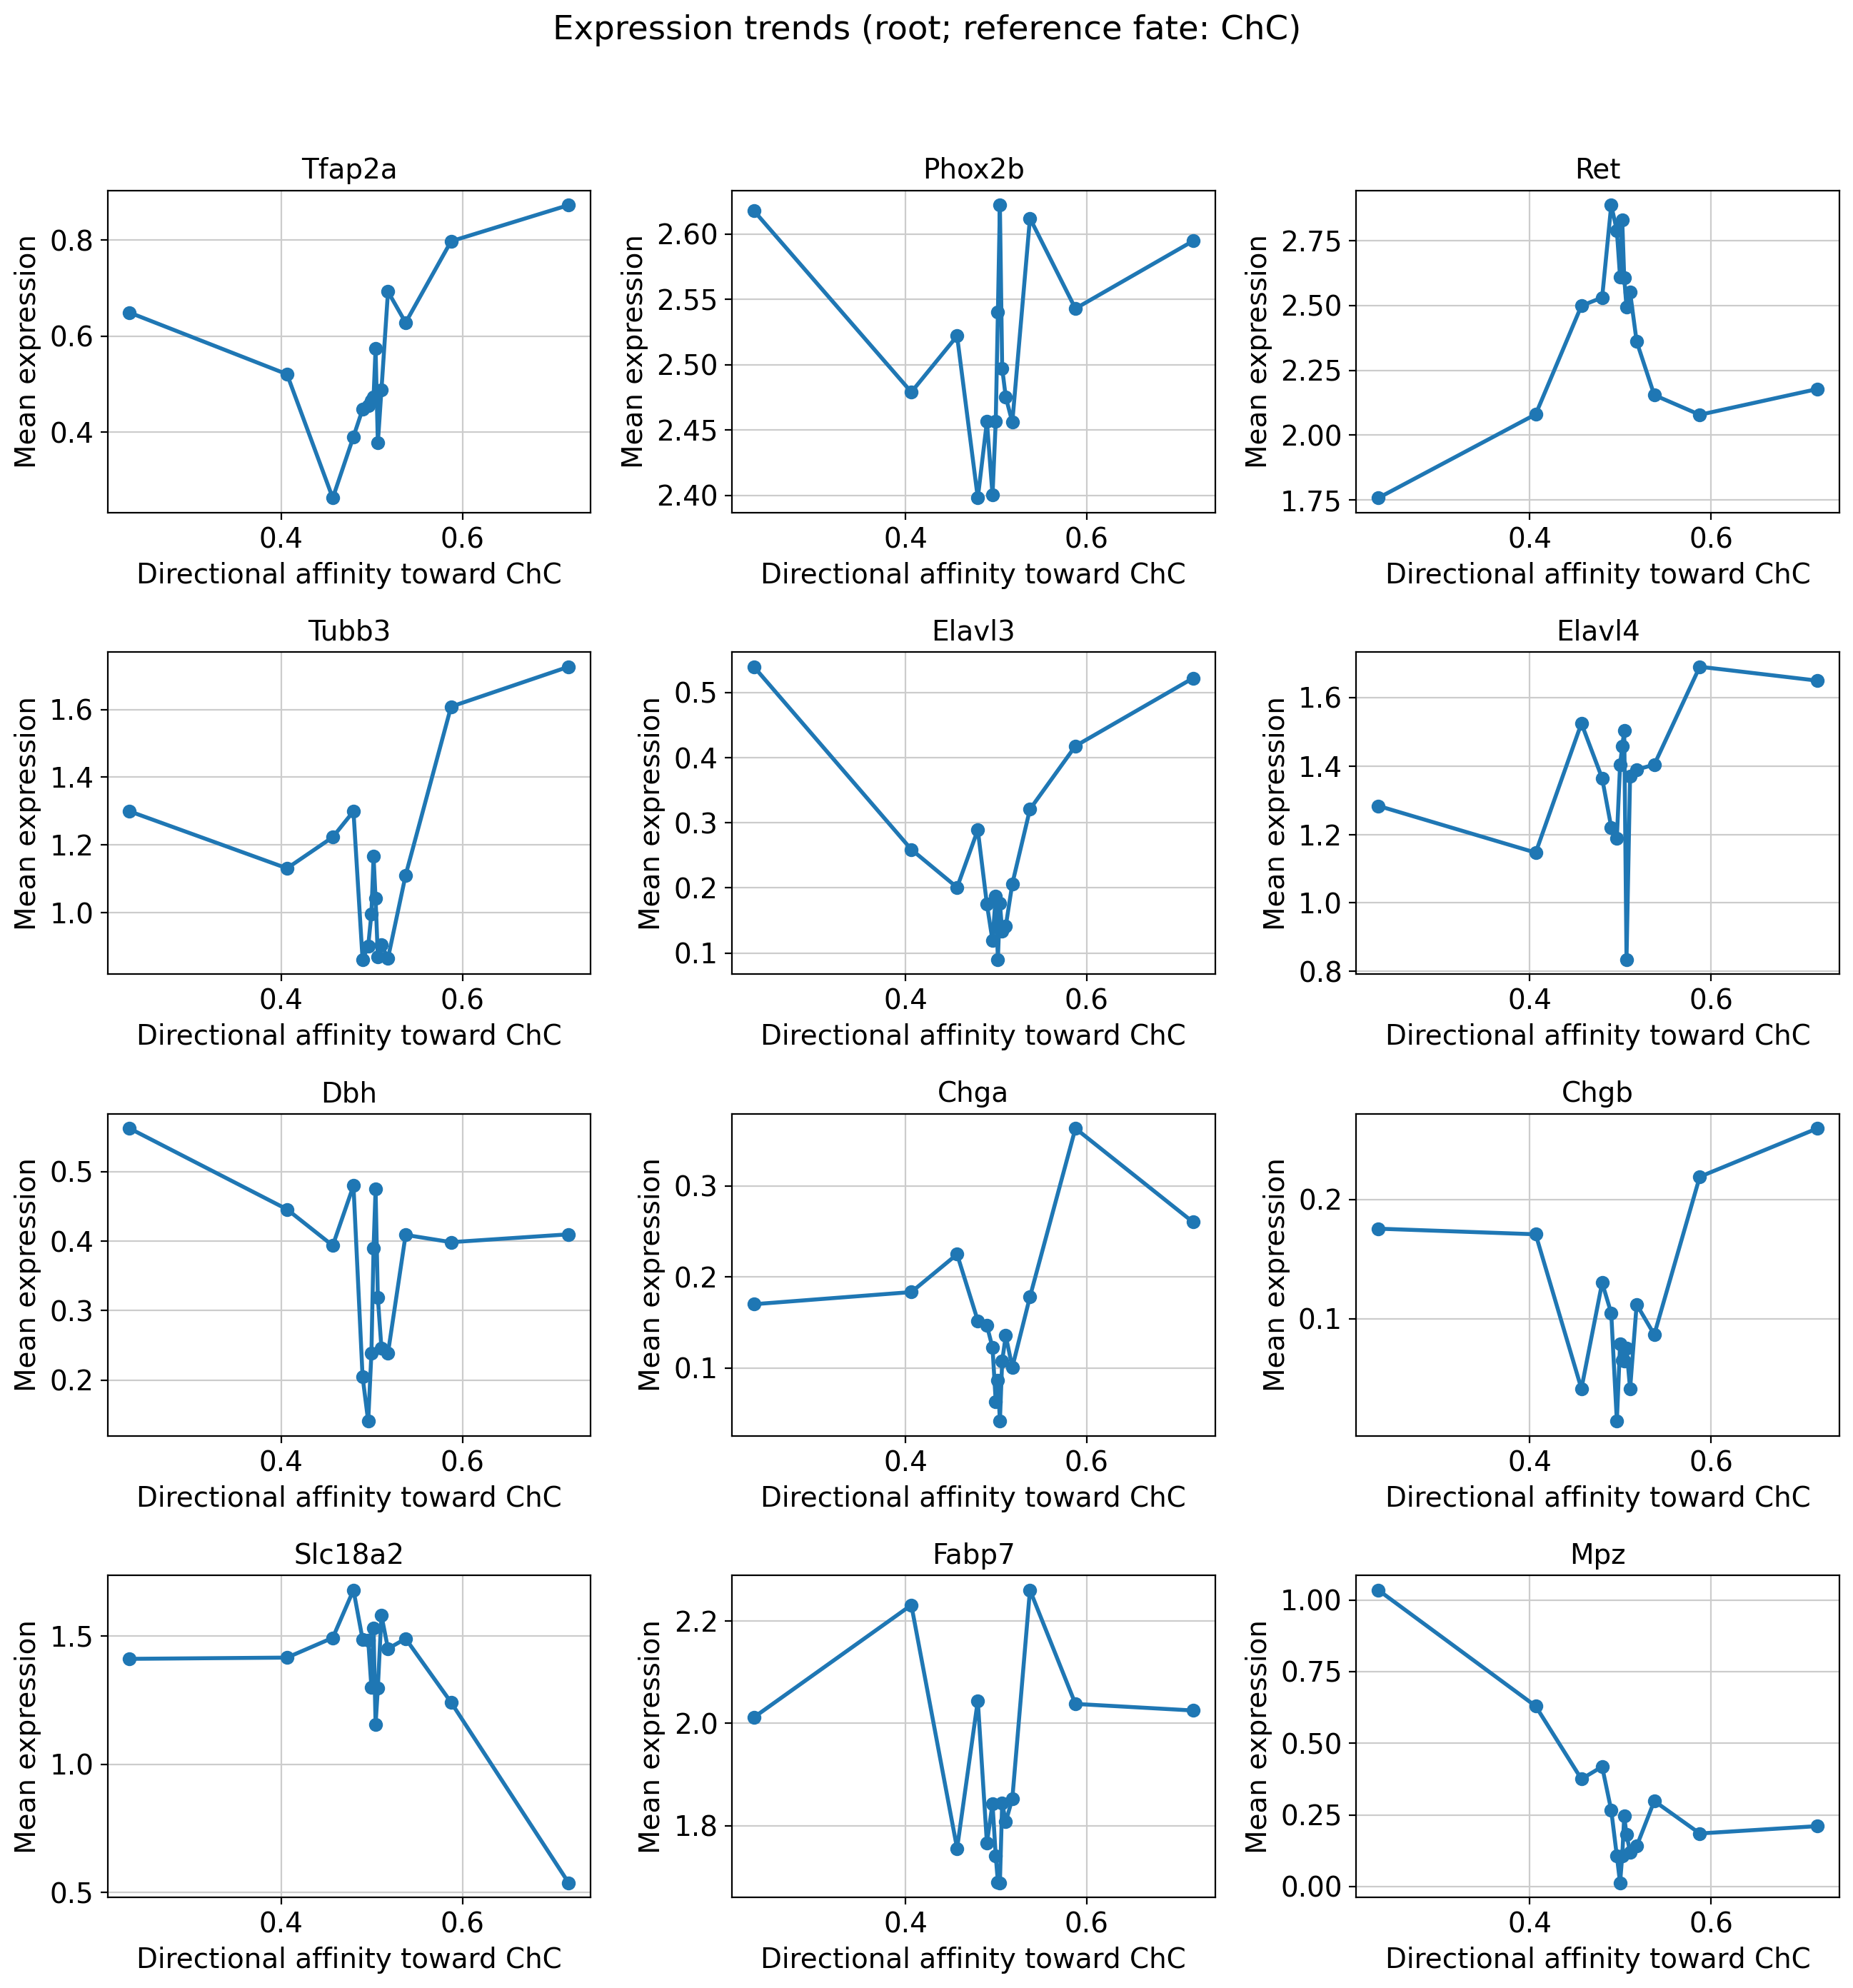

In [10]:
trend_genes = markers[:12]
ordering_trends = scorer.plot_expression_trends(
    trend_genes,
    result,
    x_axis="ordering",
    population="all",
    n_bins=20,
    ncols=3,
)
ordering_trends.savefig(
    OUTPUT_DIR / "expression_trends_ordering.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

chc_trends = scorer.plot_expression_trends(
    trend_genes,
    result,
    fate="ChC",
    x_axis="affinity",
    population="root",
    n_bins=15,
    ncols=3,
)
chc_trends.savefig(
    OUTPUT_DIR / "expression_trends_ChC_CFA.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## 9. Candidate commitment-associated genes

The public RegVelo object contains plate metadata, but plate is not guaranteed
to be an independent biological replicate and can be confounded with
developmental structure. The primary tutorial therefore treats cell-level
results as exploratory candidates. Use replicate-level inference only when the
metadata represent independent biological samples.

In [11]:
association = scorer.get_commitment_associated_genes(
    outcome="future_fate_affinity",
    fate_names=FATES,
    population="root",
    inference_unit="cell_exploratory",
    pseudotime_key=ORDERING_KEY,
    min_cells=100,
    min_feature_cells=10,
    min_feature_fraction=0.01,
    n_top_genes=50,
    verbose=True,
)
for fate in FATES:
    print("\n", fate)
    display(association.top(fate, n=20))
association.export(OUTPUT_DIR, prefix="schwann_CFA_association")


[scCS] Candidate commitment-associated genes: Gut
        inference_unit=cell_exploratory; matrix=X; n_units=675; tested_genes=811
 rank     gene   effect   pvalue_adj  significant
    1   Col5a1 0.485261 3.373593e-38         True
    2    Lama4 0.459167 7.590007e-34         True
    3    Hspg2 0.438345 1.377937e-30         True
    4     Mcam 0.433175 6.778292e-30         True
    5    Lamb1 0.410938 1.230403e-26         True
    6  Col18a1 0.372944 1.160676e-21         True
    7   Tagln2 0.369894 2.515631e-21         True
    8    Sparc 0.357539 5.845513e-20         True
    9   Sorbs1 0.337323 1.150607e-17         True
   10   Camk2b 0.332076 3.902908e-17         True
   11    Postn 0.332067 3.902908e-17         True
   12    Wwtr1 0.328782 8.119904e-17         True
   13  Micall1 0.328721 8.119904e-17         True
   14     Ngfr 0.322114 3.959277e-16         True
   15    Lamc1 0.314530 2.240800e-15         True
   16     Utrn 0.308363 9.123179e-15         True
   17   Col4a2 0.3

,gene,effect,pvalue,pvalue_adj,feature_mean,feature_sd,n_detected_cells,n_units,significant,absolute_effect,rank
0,Col5a1,0.485261,4.159794e-41,3.373593e-38,1.964407,0.947295,579,675,True,0.485261,1
1,Lama4,0.459167,1.871765e-36,7.590007e-34,1.773734,1.000479,544,675,True,0.459167,2
2,Hspg2,0.438345,5.097178e-33,1.377937e-30,0.918172,0.899727,378,675,True,0.438345,3
3,Mcam,0.433175,3.343177e-32,6.778292e-30,2.143249,0.945579,590,675,True,0.433175,4
4,Lamb1,0.410938,7.585717e-29,1.230403e-26,1.813068,0.940148,563,675,True,0.410938,5
5,Col18a1,0.372944,1.144933e-23,1.160676e-21,1.921003,0.971373,572,675,True,0.372944,6
6,Tagln2,0.369894,2.791699e-23,2.515631e-21,2.127654,1.016963,574,675,True,0.369894,7
7,Sparc,0.357539,9.370120e-22,5.845513e-20,2.890668,0.471350,668,675,True,0.357539,8
8,Sorbs1,0.337323,2.128126e-19,1.150607e-17,1.455308,1.035056,482,675,True,0.337323,9
9,Camk2b,0.332076,8.163270e-19,3.902908e-17,1.493340,0.928660,524,675,True,0.332076,10



 Gut neuron


,gene,effect,pvalue,pvalue_adj,feature_mean,feature_sd,n_detected_cells,n_units,significant,absolute_effect,rank
0,Chrnb4,0.363621,1.693978e-22,1.717270e-20,0.884235,1.126394,282,675,True,0.363621,1
1,Celf2,0.309912,1.803967e-16,4.876724e-15,2.413041,0.481743,664,675,True,0.309912,2
2,Serpini1,0.296371,3.929374e-15,8.386112e-14,1.026285,1.147788,323,675,True,0.296371,3
3,Rbp1,0.291200,1.221914e-14,2.477431e-13,3.046686,0.412748,673,675,True,0.291200,4
4,Dll1,0.285390,4.252479e-14,7.663913e-13,0.642346,1.004160,214,675,True,0.285390,5
5,Cd9,0.272488,6.123400e-13,1.056612e-11,2.153465,0.689199,631,675,True,0.272488,6
6,Phox2b,0.257167,1.215364e-11,1.699414e-10,2.511418,0.507439,666,675,True,0.257167,7
7,Slc18a2,0.251240,3.668521e-11,4.958618e-10,1.369748,1.047893,460,675,True,0.251240,8
8,Ednrb,0.245161,1.106423e-10,1.359559e-09,3.201430,0.363540,675,675,True,0.245161,9
9,Eya1,0.239936,2.791368e-10,3.107756e-09,1.019634,0.999943,379,675,True,0.239936,10



 ChC


,gene,effect,pvalue,pvalue_adj,feature_mean,feature_sd,n_detected_cells,n_units,significant,absolute_effect,rank
0,Gata3,0.320293,1.521948e-17,6.171498e-15,0.256525,0.683459,95,675,True,0.320293,1
1,Tbx20,0.265919,2.257416e-12,4.297022e-10,0.157420,0.546793,60,675,True,0.265919,2
2,Htr3a,0.265101,2.649212e-12,4.297022e-10,0.220528,0.710026,66,675,True,0.265101,3
3,Cdkn1c,0.253558,2.389436e-11,2.520190e-09,2.755475,0.681492,668,675,True,0.253558,4
4,Tfap2b,0.225580,3.179907e-09,2.578904e-07,0.435354,0.732454,198,675,True,0.225580,5
5,Pls3,0.206909,5.944413e-08,3.957827e-06,2.281151,0.961091,596,675,True,0.206909,6
6,Zdbf2,0.206474,6.344236e-08,3.957827e-06,0.520088,0.832358,208,675,True,0.206474,7
7,Adam23,0.203170,1.035380e-07,5.997808e-06,0.961757,0.977666,372,675,True,0.203170,8
8,Scrg1,0.200918,1.439102e-07,7.780744e-06,0.359461,0.726299,142,675,True,0.200918,9
9,Padi2,0.194298,3.706797e-07,1.582217e-05,0.652577,0.964456,229,675,True,0.194298,10


['tutorial_outputs/schwann_downstream/schwann_CFA_association_Gut.csv',
 'tutorial_outputs/schwann_downstream/schwann_CFA_association_Gut_neuron.csv',
 'tutorial_outputs/schwann_downstream/schwann_CFA_association_ChC.csv',
 'tutorial_outputs/schwann_downstream/schwann_CFA_association_metadata.json']

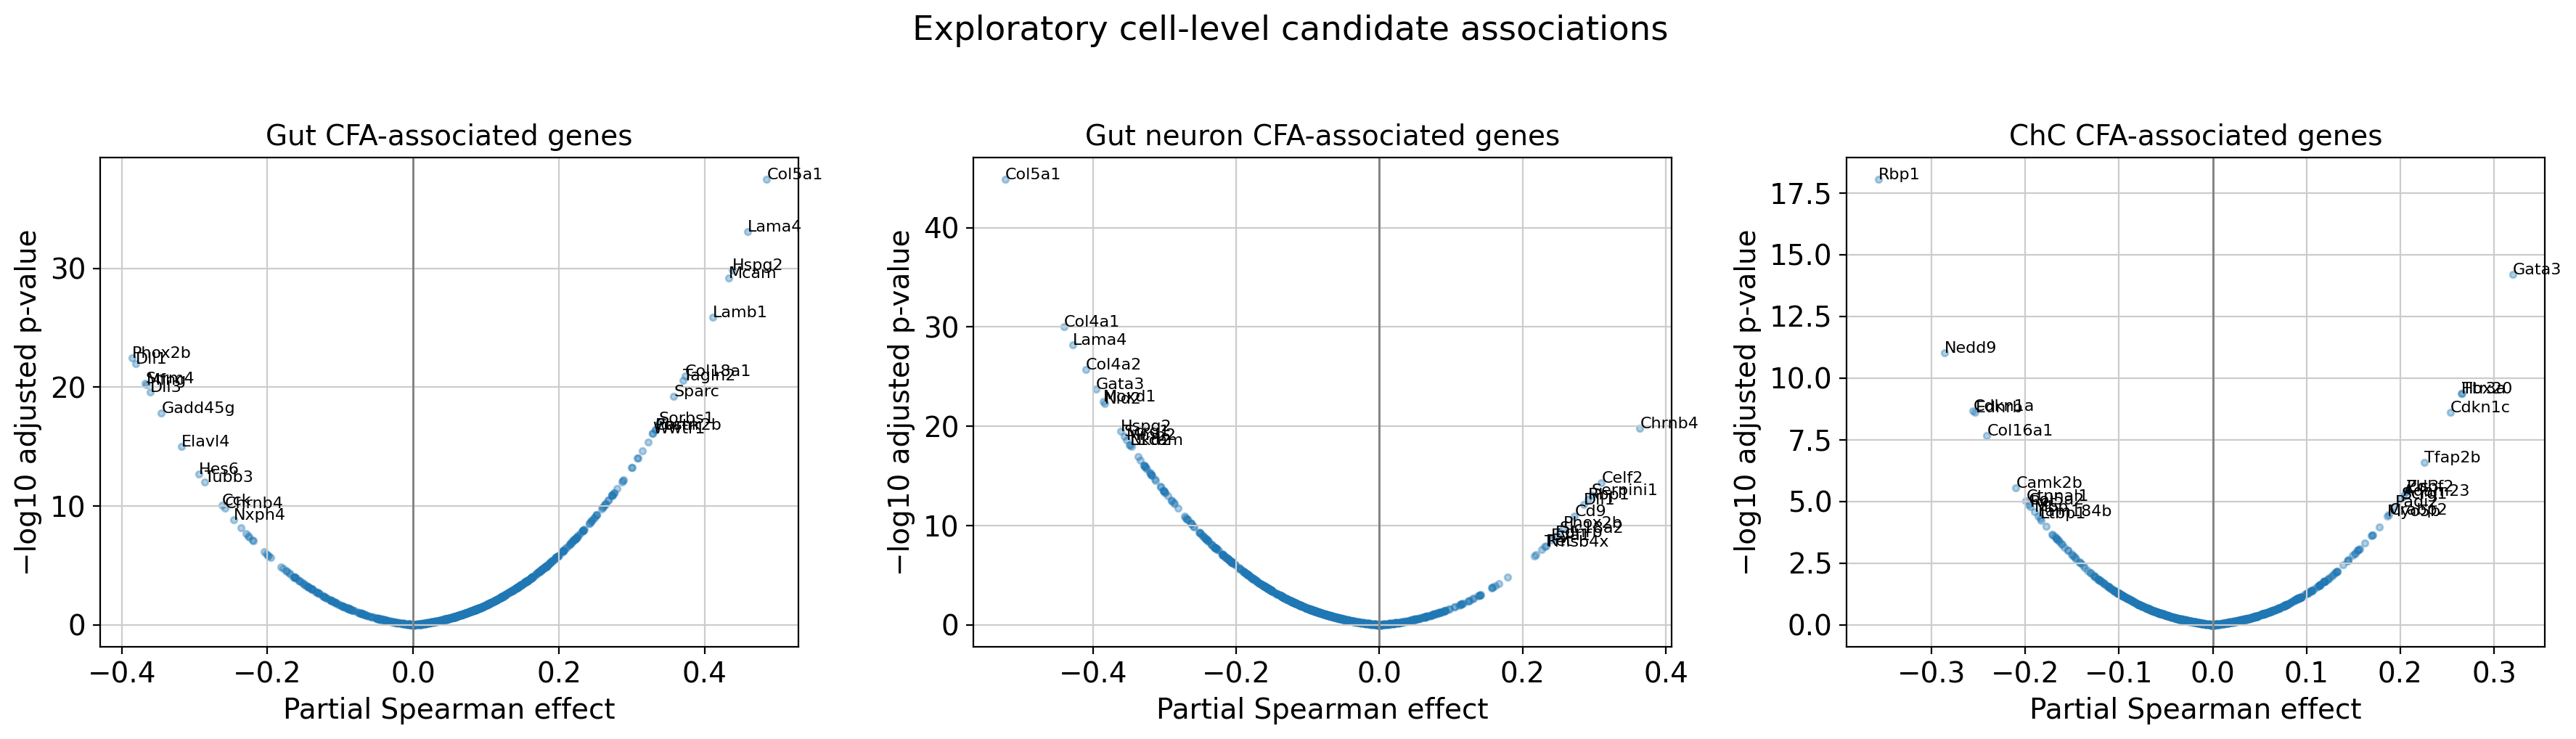

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for axis, fate in zip(axes, FATES):
    table = association.tables[fate].copy()
    shown = pd.concat(
        [
            table.nlargest(12, "effect"),
            table.nsmallest(12, "effect"),
        ]
    ).drop_duplicates("gene")
    axis.scatter(
        table["effect"],
        -np.log10(table["pvalue_adj"].clip(lower=1e-300)),
        s=10,
        alpha=0.35,
    )
    for row in shown.itertuples():
        axis.text(
            row.effect,
            -np.log10(max(row.pvalue_adj, 1e-300)),
            row.gene,
            fontsize=8,
        )
    axis.axvline(0, color="0.5", linewidth=1)
    axis.set_title(f"{fate} CFA-associated genes")
    axis.set_xlabel("Partial Spearman effect")
    axis.set_ylabel("−log10 adjusted p-value")
fig.suptitle("Exploratory cell-level candidate associations", y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "CFA_association_volcanoes.png", dpi=200, bbox_inches="tight")
plt.show()

## 10. Fate markers versus the Common Progenitor root

In [13]:
fate_markers = scorer.get_fate_markers(
    method="wilcoxon",
    fdr_threshold=0.05,
    logfc_threshold=0.25,
    min_cells=10,
    verbose=True,
)
for fate, table in fate_markers.items():
    table.to_csv(OUTPUT_DIR / f"fate_markers_{fate}.csv", index=False)
    print("\n", fate)
    display(table.head(20))

ranking genes
    finished (0:00:01)

[scCS] Fate markers: Gut vs Common Progenitor; significant=385
 rank    gene  logfoldchange    pvalue_adj
   13   Fabp1       8.236076  1.852917e-25
   14   Cryab       8.228703 2.522689e-100
   15   Ndrg1       7.812272  2.877590e-72
   16     Fos       6.614855  6.542442e-83
   17   Tppp3       6.455219  1.639030e-72
   18  Casp12       6.153129  6.797695e-16
   20   Pmp22       5.994967  3.753299e-63
   21   Ndrg2       5.870495  2.095392e-62
   22    Apoe       5.813390  3.121022e-90
   23   Grb14       5.675857  8.762239e-41
   24   Capn6       5.572762  1.027089e-79
   25 Plekhb1       5.477344  5.923082e-96
   26    Egr1       5.381674  2.231478e-51
   27    Emp1       5.322681  1.072098e-06
   28   Apoa1       5.297144  1.616097e-21
   29    Gjc3       5.103462  4.848185e-25
   30   Socs3       5.052036  3.301412e-37
   31   Lpar1       5.037060  2.942423e-27
   33    Nsg2       4.979799  2.958777e-20
   34    Xaf1       4.839970  7.558513e

,gene,score,logfoldchange,pvalue,pvalue_adj,pct_terminal,significant,analysis_type,rank
0,Nat8,0.284198,25.702930,7.762587e-01,1.000000e+00,0.012245,False,terminal_annotation_marker_vs_root,1
1,Sh2d4a,0.189465,25.398708,8.497282e-01,1.000000e+00,0.008163,False,terminal_annotation_marker_vs_root,2
2,Hnf4a,0.189465,24.745798,8.497282e-01,1.000000e+00,0.008163,False,terminal_annotation_marker_vs_root,3
3,Aadac,0.378931,24.689800,7.047394e-01,1.000000e+00,0.016327,False,terminal_annotation_marker_vs_root,4
4,Tfec,0.094733,24.473082,9.245272e-01,1.000000e+00,0.004082,False,terminal_annotation_marker_vs_root,5
5,Casp4,0.094733,24.267618,9.245272e-01,1.000000e+00,0.004082,False,terminal_annotation_marker_vs_root,6
6,Oas1a,0.094733,24.173471,9.245272e-01,1.000000e+00,0.004082,False,terminal_annotation_marker_vs_root,7
7,Tpsb2,0.094733,23.755999,9.245272e-01,1.000000e+00,0.004082,False,terminal_annotation_marker_vs_root,8
8,Clec9a,0.094733,23.206762,9.245272e-01,1.000000e+00,0.004082,False,terminal_annotation_marker_vs_root,9
9,Ckm,0.094733,22.682152,9.245272e-01,1.000000e+00,0.004082,False,terminal_annotation_marker_vs_root,10



 Gut neuron


,gene,score,logfoldchange,pvalue,pvalue_adj,pct_terminal,significant,analysis_type,rank
0,Coro6,0.252798,25.685667,0.800424,1.0,0.010204,False,terminal_annotation_marker_vs_root,1
1,Steap4,0.168532,24.806101,0.866165,1.0,0.006803,False,terminal_annotation_marker_vs_root,2
2,Hnf4a,0.252798,24.803745,0.800424,1.0,0.010204,False,terminal_annotation_marker_vs_root,3
3,Oas1a,0.168532,24.519466,0.866165,1.0,0.006803,False,terminal_annotation_marker_vs_root,4
4,Aadac,0.168532,24.462461,0.866165,1.0,0.006803,False,terminal_annotation_marker_vs_root,5
5,Clec5a,0.168532,24.336710,0.866165,1.0,0.006803,False,terminal_annotation_marker_vs_root,6
6,Ces2g,0.168532,24.248285,0.866165,1.0,0.006803,False,terminal_annotation_marker_vs_root,7
7,Gm6249,0.168532,24.226959,0.866165,1.0,0.006803,False,terminal_annotation_marker_vs_root,8
8,Sh2d4a,0.084266,24.171911,0.932845,1.0,0.003401,False,terminal_annotation_marker_vs_root,9
9,Hepacam,0.084266,24.071209,0.932845,1.0,0.003401,False,terminal_annotation_marker_vs_root,10



 ChC


,gene,score,logfoldchange,pvalue,pvalue_adj,pct_terminal,significant,analysis_type,rank
0,Coro6,0.472877,25.427753,0.636301,0.947858,0.014436,False,terminal_annotation_marker_vs_root,1
1,Oas1a,0.343911,24.870636,0.730914,1.000000,0.010499,False,terminal_annotation_marker_vs_root,2
2,Fcgr3,0.386899,24.817179,0.698831,1.000000,0.011811,False,terminal_annotation_marker_vs_root,3
3,Mx1,0.214944,24.580645,0.829811,1.000000,0.006562,False,terminal_annotation_marker_vs_root,4
4,Pbld1,0.214944,24.179266,0.829811,1.000000,0.006562,False,terminal_annotation_marker_vs_root,5
5,Pck1,0.257933,24.114807,0.796459,1.000000,0.007874,False,terminal_annotation_marker_vs_root,6
6,Ckm,0.214944,23.798058,0.829811,1.000000,0.006562,False,terminal_annotation_marker_vs_root,7
7,Gm6249,0.128966,23.489582,0.897384,1.000000,0.003937,False,terminal_annotation_marker_vs_root,8
8,Chrna2,0.085978,23.459509,0.931484,1.000000,0.002625,False,terminal_annotation_marker_vs_root,9
9,Hrg,0.085978,23.173508,0.931484,1.000000,0.002625,False,terminal_annotation_marker_vs_root,10


In [14]:
overlap_rows = []
for fate in FATES:
    association_genes = set(association.top(fate, n=100, positive_only=True)["gene"])
    marker_genes = set(fate_markers[fate].head(100)["gene"])
    overlap_rows.append(
        {
            "fate": fate,
            "top_association_genes": len(association_genes),
            "top_marker_genes": len(marker_genes),
            "overlap": len(association_genes & marker_genes),
            "overlap_genes": ", ".join(sorted(association_genes & marker_genes)),
        }
    )
overlap_table = pd.DataFrame(overlap_rows)
display(overlap_table)
overlap_table.to_csv(OUTPUT_DIR / "association_marker_overlap.csv", index=False)

,fate,top_association_genes,top_marker_genes,overlap,overlap_genes
0,Gut,100,100,14,"Afap1l2, Col4a1, Cryab, Entpd2, Ndrg2, Nfia, P..."
1,Gut neuron,100,100,19,"Adcyap1r1, Chrnb2, Chrnb4, Cplx1, Dlg2, Doc2b,..."
2,ChC,100,100,14,"AW551984, Dlk1, Gata2, Gata3, Isl1, Meg3, Nduf..."


## 11. Local pathway enrichment

The local mapping below is a compact tutorial resource. Replace it with a
versioned neural-crest/enteric-neuron GMT collection for final biological
analysis.

In [15]:
local_gene_sets = {
    "neural_crest_progenitor_program": {
        "Sox10", "Foxd3", "Tfap2a", "Tfap2b", "Erbb3", "Plp1",
    },
    "enteric_neuron_program": {
        "Phox2b", "Ret", "Tubb3", "Elavl3", "Elavl4", "Sox10",
    },
    "catecholamine_biosynthesis": {
        "Th", "Dbh", "Ddc", "Slc18a2", "Chga", "Chgb",
    },
    "neuronal_maturation": {
        "Tubb3", "Map2", "Stmn2", "Snap25", "Syp", "Elavl3",
    },
    "schwann_glial_program": {
        "Sox10", "Plp1", "S100b", "Fabp7", "Mpz", "Erbb3",
    },
    "secretory_granules": {
        "Chga", "Chgb", "Scg2", "Scg3", "Scg5", "Cpe",
    },
}
present = set(map(str, adata.var_names))
local_gene_sets = {
    term: sorted(set(genes) & present)
    for term, genes in local_gene_sets.items()
}
display(pd.Series({term: len(genes) for term, genes in local_gene_sets.items()}, name="n_genes"))

neural_crest_progenitor_program    2
enteric_neuron_program             5
catecholamine_biosynthesis         5
neuronal_maturation                5
schwann_glial_program              2
secretory_granules                 6
Name: n_genes, dtype: int64

[scCS] Enrichment Gut: query_genes=150, significant_terms=0
[scCS] Enrichment Gut neuron: query_genes=89, significant_terms=3
[scCS] Enrichment ChC: query_genes=150, significant_terms=0


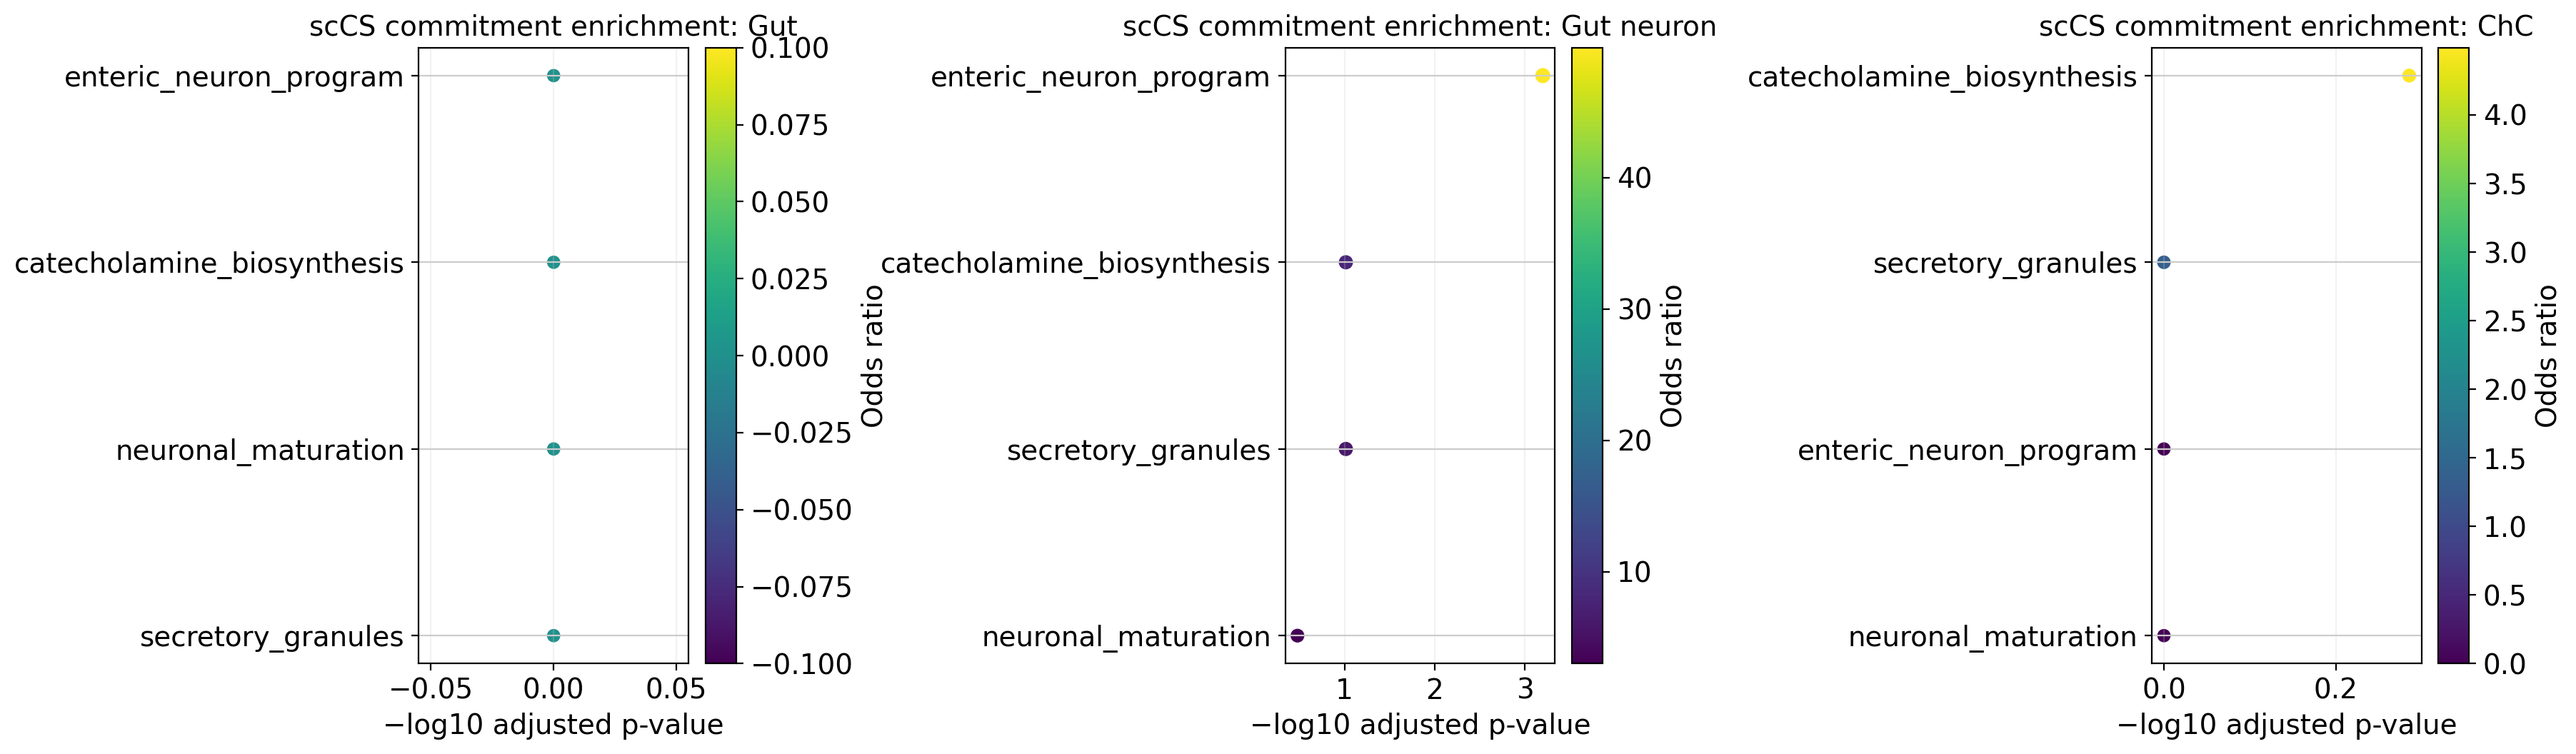

In [16]:
enrichment = scCS.run_commitment_enrichment(
    association,
    gene_sets=local_gene_sets,
    background=adata.var_names,
    direction="positive",
    effect_threshold=0.05,
    significant_only=False,
    max_genes=150,
    min_query_genes=3,
    min_set_size=3,
    fdr_threshold=0.10,
    verbose=True,
)
enrichment.export(OUTPUT_DIR, prefix="schwann_local_enrichment")

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for axis, fate in zip(axes, FATES):
    scCS.plot_enrichment_dotplot(
        enrichment,
        fate,
        n_terms=10,
        significant_only=False,
        ax=axis,
    )
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "local_enrichment_dotplots.png", dpi=200, bbox_inches="tight")
plt.show()

## 12. Early, middle, and late profiles within each annotated population

A sign change in SOF across ordering thirds can indicate a turn or return.
Uniformly negative SOF supports broadly retrograde behavior.

,cell_type_new,ordering_third,n_cells,mean_DFR,mean_FFS,mean_SOF,forward_fraction
0,ChC,early,254,0.636289,0.713421,0.098101,0.877953
1,ChC,late,254,0.942397,0.992322,-0.019654,0.401575
2,ChC,middle,254,0.844323,0.918113,0.039577,0.744094
3,Common Progenitor,early,225,0.157488,0.138898,0.159385,1.000000
4,Common Progenitor,late,225,0.140006,0.096235,-0.146589,0.160000
5,Common Progenitor,middle,225,0.169404,0.133746,0.047846,0.728889
6,Gut,early,82,0.257597,0.070739,-0.172219,0.256098
7,Gut,late,82,0.569632,0.439998,-0.147717,0.000000
8,Gut,middle,81,0.335691,0.124006,-0.147658,0.061728
9,Gut neuron,early,98,0.719186,0.650092,0.111157,0.938776


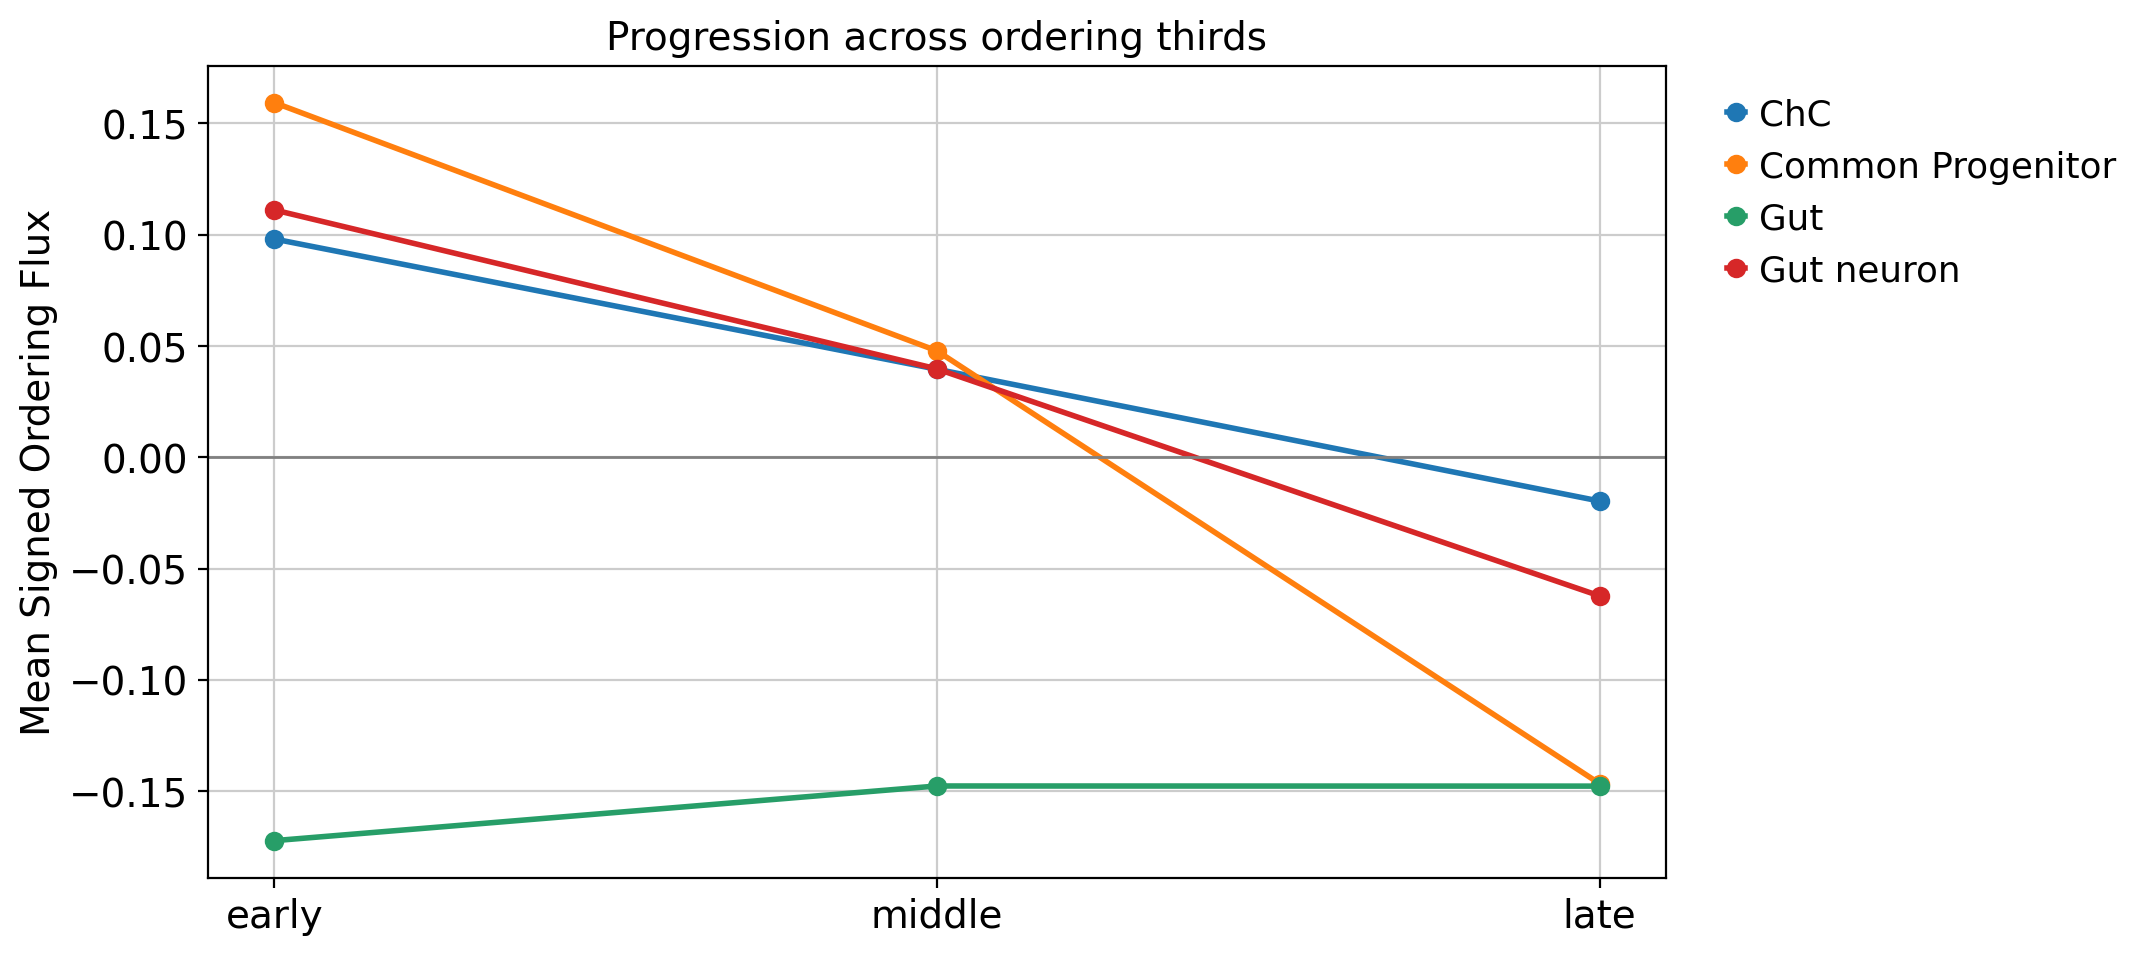

In [17]:
selected_obs = adata.obs.loc[result.cell_ids, ["cell_type_new", ORDERING_KEY]].copy()
selected_obs["DFR"] = result.discounted_fate_reach
selected_obs["FFS"] = result.future_fate_specificity
selected_obs["SOF"] = result.signed_ordering_flux
selected_obs["ordering_third"] = "middle"

for population, indices in selected_obs.groupby("cell_type_new", observed=True).groups.items():
    ranks = selected_obs.loc[indices, ORDERING_KEY].rank(method="first")
    selected_obs.loc[indices, "ordering_third"] = pd.qcut(
        ranks,
        q=3,
        labels=["early", "middle", "late"],
    ).astype(str)

third_summary = (
    selected_obs.groupby(
        ["cell_type_new", "ordering_third"],
        observed=True,
    )
    .agg(
        n_cells=("DFR", "size"),
        mean_DFR=("DFR", "mean"),
        mean_FFS=("FFS", "mean"),
        mean_SOF=("SOF", "mean"),
        forward_fraction=("SOF", lambda values: float(np.mean(values > 0))),
    )
    .reset_index()
)
display(third_summary)

fig, ax = plt.subplots(figsize=(11, 5))
for population, table in third_summary.groupby("cell_type_new", observed=True):
    ordered = table.set_index("ordering_third").reindex(["early", "middle", "late"])
    ax.plot(
        ["early", "middle", "late"],
        ordered["mean_SOF"],
        marker="o",
        linewidth=2,
        label=population,
    )
ax.axhline(0, color="0.5", linewidth=1)
ax.set_ylabel("Mean Signed Ordering Flux")
ax.set_title("Progression across ordering thirds")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "ordering_thirds_SOF.png", dpi=200, bbox_inches="tight")
plt.show()

## 13. Replicate-level inference template

When `sample_id` is a genuine biological replicate:

```python
association_replicate = scorer.get_commitment_associated_genes(
    outcome="future_fate_affinity",
    fate_names=FATES,
    population="root",
    inference_unit="replicate",
    replicate_key="sample_id",
    condition_key="condition",
    pseudotime_key=ORDERING_KEY,
    min_replicates=6,
    min_cells_per_replicate=5,
)
```

Do not use plate, library, or pseudo-condition labels as biological replicates
unless the study design justifies that interpretation.

## 14. Export the complete downstream record

In [18]:
summary_table.to_csv(OUTPUT_DIR / "cell_level_DFFP_metrics.csv", index=False)
third_summary.to_csv(OUTPUT_DIR / "ordering_thirds_summary.csv", index=False)
adata.write_h5ad(OUTPUT_DIR / "schwann_downstream_analysis.h5ad")

metadata = {
    "scoring_method": "Discounted Future-Fate Propagation",
    "scoring_mode": "future_fate",
    "velocity_model": "dynamical",
    "ordering_key": ORDERING_KEY,
    "effective_horizon": FUTURE_OPTIONS["effective_horizon"],
    "anchor_quantile": FUTURE_OPTIONS["anchor_quantile"],
    "association_scope": "cell_exploratory_candidate_generation",
    "enrichment_source": "local_in_notebook_mapping",
    "retrograde_Gut_is_not_corrected": True,
}
pd.Series(metadata).to_json(
    OUTPUT_DIR / "downstream_metadata.json",
    indent=2,
)
print("Outputs written to", OUTPUT_DIR.resolve())

Outputs written to /home/emil/notebooks/08-tutorials/tutorial_outputs/schwann_downstream


## Interpretation checklist

- Treat inverse CytoTRACE as benchmark-specific.
- Preserve retrograde Gut SOF.
- Distinguish root commitment associations from terminal identity markers.
- Do not call exploratory cell-level associations causal drivers.
- Record the exact gene-set collection and tested-gene background.
- Use independent biological replicates for formal inference.